In [9]:
import argparse
import os
import re

import torch.nn.functional as F

os.environ["TORCHINDUCTOR_DISABLE"] = "1"
os.environ["TORCH_COMPILE"] = "0"
os.environ["TORCHDYNAMO_DISABLE"] = "1"
os.environ["DISABLE_TORCH_COMPILE"] = "1"
os.environ["TRANSFORMERS_NO_COMPILE"] = "1"
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from safetensors.torch import load_file as load_safetensors
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (adjusted_rand_score, balanced_accuracy_score,
                             calinski_harabasz_score, classification_report,
                             davies_bouldin_score, pairwise_distances,
                             silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import umap
import glob


In [2]:
models = [ "google/gemma-2-2b-it", "meta-llama/Llama-3.2-3B-Instruct", "google/gemma-2-2b", "meta-llama/Llama-3.2-3B",
           "Qwen/Qwen2.5-3B", "Qwen/Qwen2.5-3B-Instruct", "allenai/OLMo-2-0425-1B", "allenai/OLMo-2-0425-1B-Instruct"]


output_dir = "/data/erblina/Master_thesis"

datasets_list = ["walledai/DTStereotype", "walledai/CatHarmfulQA","walledai/DTToxicity","truthfulqa/truthful_qa"]


model_steering_1 = {'Qwen/Qwen2.5-3B': {'layers': [ 'model.layers.19', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 1.6, 1.6, 1.6], 'alphas_down': [ -1.8, -2.0, -2.0], 'max_avg_tox': [0.87, 0.87, 0.795, 0.76], 'min_avg_tox': [0.21, 0.21, 0.22, 0.19]},
    'Qwen/Qwen2.5-3B-Instruct': {'layers': [ 'model.layers.21', 'model.layers.20', 'model.layers.22'], 'alphas_up': [ 2.0, 2.0, 2.0], 'alphas_down': [ -0.6, -0.6, -0.6], 'max_avg_tox': [0.79, 0.79, 0.785, 0.78], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B-Instruct': {'layers': [ 'model.layers.9', 'model.layers.7', 'model.layers.8'], 'alphas_up': [ 2.0, 1.8, 1.6], 'alphas_down': [ -0.8, -1.0, -0.8], 'max_avg_tox': [0.75, 0.75, 0.735, 0.715], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'allenai/OLMo-2-0425-1B': {'layers': ['model.layers.5', 'model.layers.7', 'model.layers.4'], 'alphas_up': [-0.15, -0.07, 0.05], 'alphas_down': [-2.0, -1.5, -2.0], 'max_avg_tox': [0.4, 0.39, 0.39], 'min_avg_tox': [0.09, 0.085, 0.09]},
    'google/gemma-2-2b-it': {'layers': [ 'model.layers.10', 'model.layers.11', 'model.layers.12'], 'alphas_up': [ 1.5, 1.1, 1.0], 'alphas_down': [-0.3, -0.25, -0.2], 'max_avg_tox': [0.63, 0.63, 0.615, 0.595], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'meta-llama/Llama-3.2-3B-Instruct': {'layers': [ 'model.layers.12', 'model.layers.13', 'model.layers.14'], 'alphas_up': [ 2.0, 1.6, 2.0], 'alphas_down': [ -0.8, -0.5, -0.5], 'max_avg_tox': [0.82, 0.82, 0.81, 0.79], 'min_avg_tox': [0.0, 0.0, 0.0, 0.0]},
    'google/gemma-2-2b': {'layers': [ 'model.layers.6', 'model.layers.7', 'model.layers.13'], 'alphas_up': [ 1.2, 1.3, 1.4], 'alphas_down': [ -2.0, -1.8, -1.8], 'max_avg_tox': [0.36, 0.36, 0.35, 0.36], 'min_avg_tox': [0.135, 0.02, 0.035, 0.065]},
    'meta-llama/Llama-3.2-3B': {'layers': [ 'model.layers.12', 'model.layers.10', 'model.layers.11'], 'alphas_up': [ 0.7, 1.0, 1.0], 'alphas_down': [ -2.0, -1.4, -1.6], 'max_avg_tox': [0.605, 0.57, 0.575, 0.6], 'min_avg_tox': [0.385, 0.3, 0.33, 0.36]},
        }

In [3]:
def load_harmbench(model, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    ###### HARMBENCH DATASET ######
    labels = np.load(f"{output_dir}/{safe_model_name}/labels.npy")
    hidden_states = load_safetensors(
        os.path.join(f"{output_dir}/{safe_model_name}", f"hidden_states_pure.safetensors"))
    
    side = 'toxic'
    # # Define path pattern
    # pattern = f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_*.npy"

    # # Find all matching files
    # files = sorted(glob.glob(pattern))

    # # Load them into a dictionary keyed by alpha
    # data = {}
    # for file in files:
    #     # Extract the alpha value from filename
    #     alpha_str = os.path.splitext(os.path.basename(file))[0].split('_alpha_')[-1]
    #     alpha = float(alpha_str)
    #     data[alpha] = np.load(file, allow_pickle=True).item()

    return hidden_states, labels #, data

def load_datasets(model, dataset, output_dir):
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)

    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
    hidden_states_data = load_safetensors(os.path.join(output_dir, safe_model_name, f"{safe_dataset}_hidden_states_pure.safetensors"))
    labels_data = np.load(f"{output_dir}/{safe_model_name}/labels_{safe_dataset}.npy")

    return hidden_states_data, labels_data

def load_steering_dataset(model, dataset, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
    safe_dataset = re.sub(r'[\\/*?:"<>|]', "_", dataset)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after_dataset = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_dataset_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{safe_dataset}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after_dataset,
            alpha_d : labels_after_dataset_d
        }

    return data

def load_steering_harmbench(model, model_steering_1, output_dir):
    side = 'toxic'
    safe_model_name = re.sub(r'[\\/*?:"<>|]', "_", model)
        # Find the layer corresponding to the given alpha
    layers = model_steering_1[model]['layers']
    data = {}
    for layer in layers:
        alpha = model_steering_1[model]['alphas_up'][layers.index(layer)] # or alphas_down
        labels_after = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha}_{layer}.npy", allow_pickle=True).item()[layer]

        alpha_d = model_steering_1[model]['alphas_down'][layers.index(layer)]
        labels_after_d = np.load(
                f"{output_dir}/{safe_model_name}/labels_steering_{side}_alpha_{alpha_d}_{layer}.npy", allow_pickle=True).item()[layer]

        data[layer] = {
            alpha : labels_after,
            alpha_d : labels_after_d
        }

    return data


In [4]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap  # <-- add this import


def plot_dim_reduction_comparison(X, y):
    n_neighbors = 5
    random_state = 0

    X_c = np.concatenate(X, axis=0)
    y_c = np.concatenate(y, axis=0)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.5, stratify=y_c, random_state=random_state
    )

    dim = len(X_c[0])
    n_classes = len(np.unique(y_c))

    # Reduce dimension to 2 with PCA
    pca = make_pipeline(StandardScaler(), PCA(n_components=2, random_state=random_state))

    # Reduce dimension to 2 with LinearDiscriminantAnalysis
    lda = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=2))

    # Reduce dimension to 2 with NeighborhoodComponentAnalysis
    nca = make_pipeline(
        StandardScaler(),
        NeighborhoodComponentsAnalysis(n_components=2, random_state=random_state),
    )

    # Use a nearest neighbor classifier to evaluate the methods
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)

    # Make a list of the methods to be compared
    dim_reduction_methods = [("PCA", pca), ("NCA", nca)] #("LDA", lda)] #, 
    c = plt.cm.get_cmap("Set1", len(X))
    # plt.figure()
    for i, (name, model) in enumerate(dim_reduction_methods):
        plt.figure()
        # plt.subplot(1, 3, i + 1, aspect=1)

        # Fit the method's model
        model.fit(X_train, y_train)

        # Fit a nearest neighbor classifier on the embedded training set
        knn.fit(model.transform(X_train), y_train)

        # Compute the nearest neighbor accuracy on the embedded test set
        acc_knn = knn.score(model.transform(X_test), y_test)

        for i, (X_, y_) in enumerate(zip(X, y)):
            # Embed the data set in 2 dimensions using the fitted model
            X_embedded = model.transform(X_)

            # Plot the projected points and show the evaluation score
            plt.scatter(X_embedded[:, 0][y_ == 0], X_embedded[:, 1][y_ == 0], c=c(i), s=30, alpha=0.3, marker='o', zorder=1)

            plt.scatter(X_embedded[:, 0][y_ == 1], X_embedded[:, 1][y_ == 1], c=c(i), s=80, alpha=0.7, marker='x', zorder=1)

        plt.title(
            "{}, KNN (k={})\nTest accuracy = {:.2f}".format(name, n_neighbors, acc_knn)
        )
    plt.show()
    plt.close()


Processing model: google/gemma-2-2b-it, layer: model.layers.10
2 198
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
788 364
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
788 364
16 534
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
16 534
2 1194
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
2 1194
44 393
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
44 393


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: google/gemma-2-2b-it, layer: model.layers.11
2 198
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
788 364
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
788 364
16 534
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
16 534
2 1194
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
2 1194
44 393
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
44 393


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: google/gemma-2-2b-it, layer: model.layers.12
2 198
2 198
Model: google/gemma-2-2b-it, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
788 364
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
788 364
16 534
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
16 534
2 1194
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
2 1194
44 393
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
44 393


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


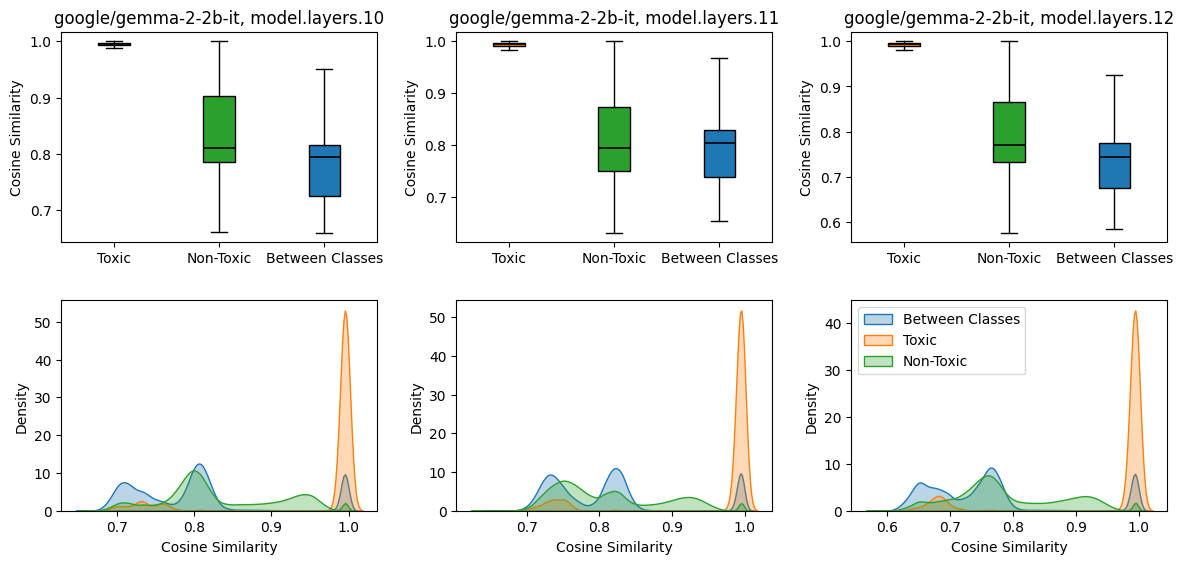

Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.12
26 174
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
253 899
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
34 516
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
30 1166
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
62 375


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.13
26 174
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
253 899
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
34 516
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
30 1166
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
62 375


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B-Instruct, layer: model.layers.14
26 174
26 174
Model: meta-llama/Llama-3.2-3B-Instruct, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
253 899
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
253 899
34 516
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
34 516
30 1166
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
30 1166
62 375
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
62 375


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


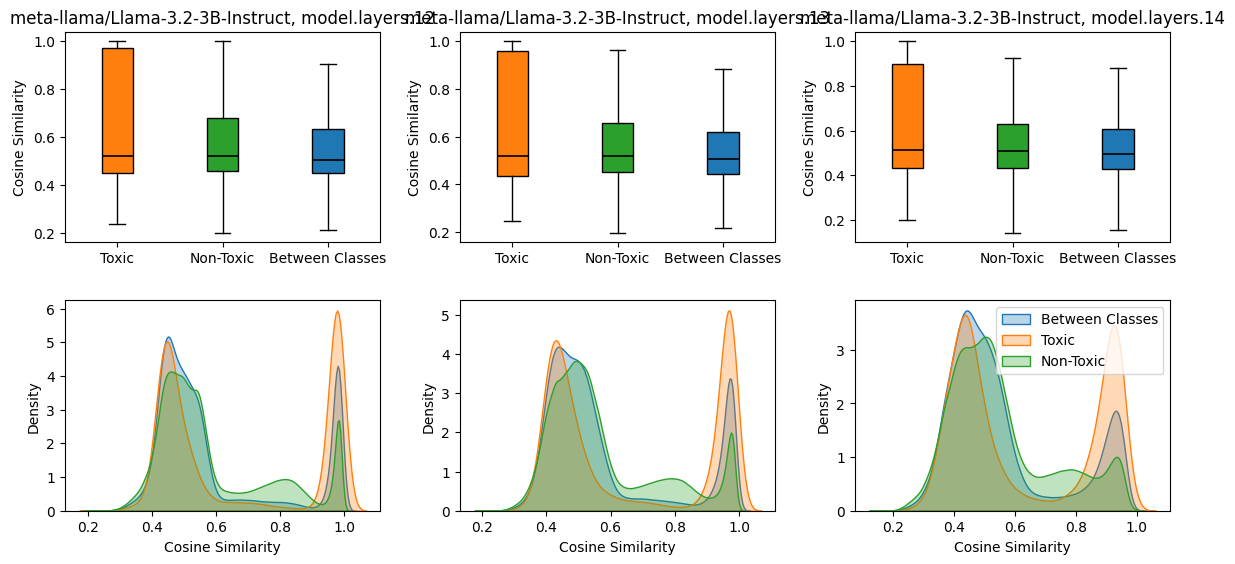

Processing model: google/gemma-2-2b, layer: model.layers.6
14 186
14 186
Model: google/gemma-2-2b, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
9 1143
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
9 1143
153 397
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
153 397
228 968
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
228 968
108 329
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
108 329


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: google/gemma-2-2b, layer: model.layers.7
14 186
14 186
Model: google/gemma-2-2b, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
9 1143
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
9 1143
153 397
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
153 397
228 968
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
228 968
108 329
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
108 329


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: google/gemma-2-2b, layer: model.layers.13
14 186
14 186
Model: google/gemma-2-2b, Hidden states shape: torch.Size([200, 2304]), Labels shape: (200,)
9 1143
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2304]), Labels shape: (1152,)
9 1143
153 397
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2304]), Labels shape: (550,)
153 397
228 968
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2304]), Labels shape: (1196,)
228 968
108 329
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2304]), Labels shape: (437,)
108 329


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


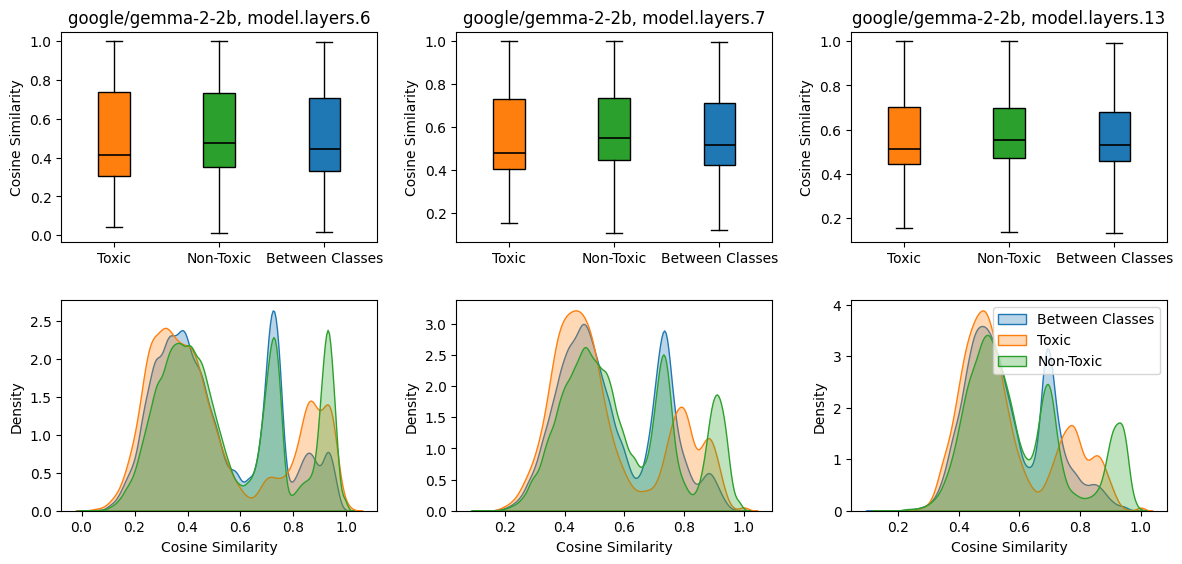

Processing model: meta-llama/Llama-3.2-3B, layer: model.layers.12
95 105
95 105
Model: meta-llama/Llama-3.2-3B, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
44 1108
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
44 1108
197 353
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
197 353
187 1009
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
187 1009
104 333
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
104 333


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B, layer: model.layers.10
95 105
95 105
Model: meta-llama/Llama-3.2-3B, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
44 1108
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
44 1108
197 353
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
197 353
187 1009
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
187 1009
104 333
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
104 333


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: meta-llama/Llama-3.2-3B, layer: model.layers.11
95 105
95 105
Model: meta-llama/Llama-3.2-3B, Hidden states shape: torch.Size([200, 3072]), Labels shape: (200,)
44 1108
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 3072]), Labels shape: (1152,)
44 1108
197 353
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 3072]), Labels shape: (550,)
197 353
187 1009
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 3072]), Labels shape: (1196,)
187 1009
104 333
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 3072]), Labels shape: (437,)
104 333


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


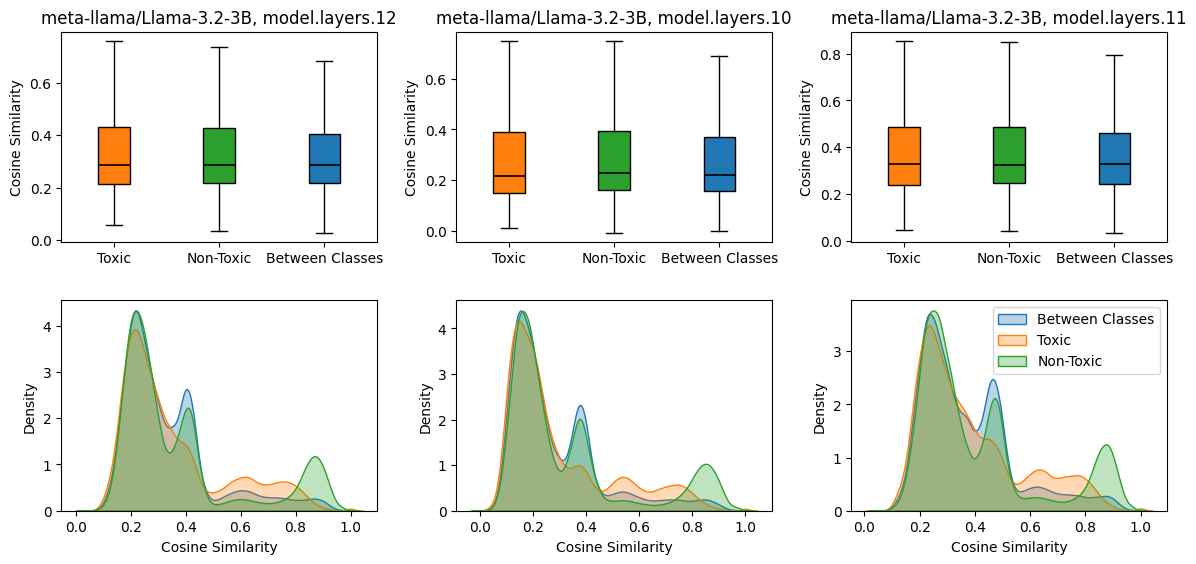

Processing model: Qwen/Qwen2.5-3B, layer: model.layers.19
133 67
133 67
Model: Qwen/Qwen2.5-3B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
411 741
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
411 741
242 308
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
242 308
392 804
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
392 804
152 285
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
152 285


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: Qwen/Qwen2.5-3B, layer: model.layers.20
133 67
133 67
Model: Qwen/Qwen2.5-3B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
411 741
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
411 741
242 308
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
242 308
392 804
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
392 804
152 285
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
152 285


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: Qwen/Qwen2.5-3B, layer: model.layers.22
133 67
133 67
Model: Qwen/Qwen2.5-3B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
411 741
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
411 741
242 308
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
242 308
392 804
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
392 804
152 285
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
152 285


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


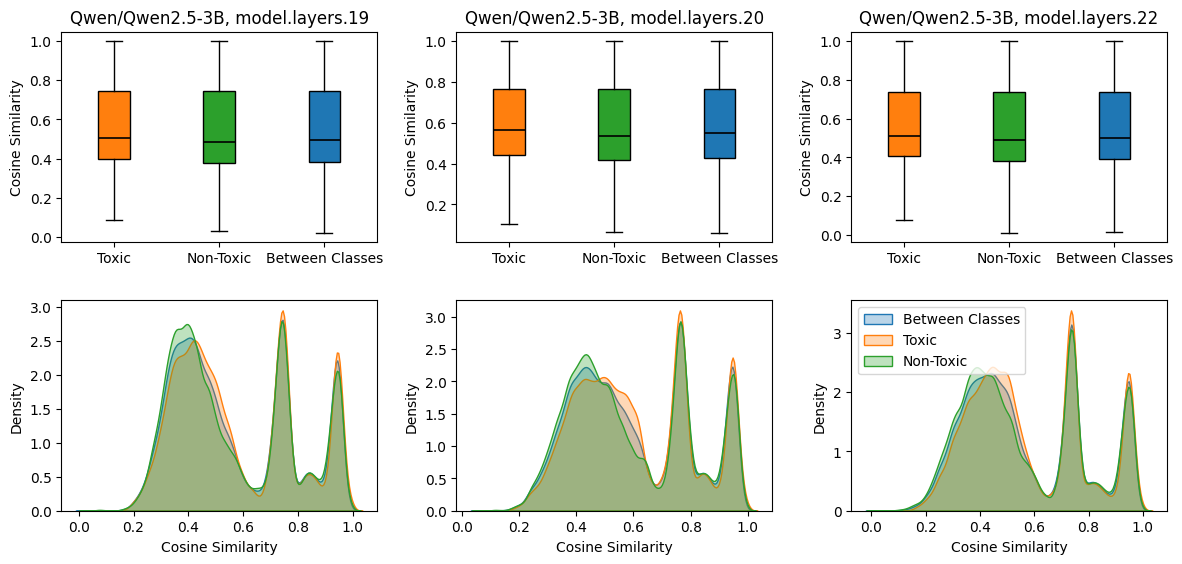

Processing model: Qwen/Qwen2.5-3B-Instruct, layer: model.layers.21
10 190
10 190
Model: Qwen/Qwen2.5-3B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
14 536
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
14 536
5 1191
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
5 1191
40 397
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
40 397


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: Qwen/Qwen2.5-3B-Instruct, layer: model.layers.20
10 190
10 190
Model: Qwen/Qwen2.5-3B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
14 536
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
14 536
5 1191
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
5 1191
40 397
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
40 397


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: Qwen/Qwen2.5-3B-Instruct, layer: model.layers.22
10 190
10 190
Model: Qwen/Qwen2.5-3B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
14 536
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
14 536
5 1191
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
5 1191
40 397
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
40 397


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


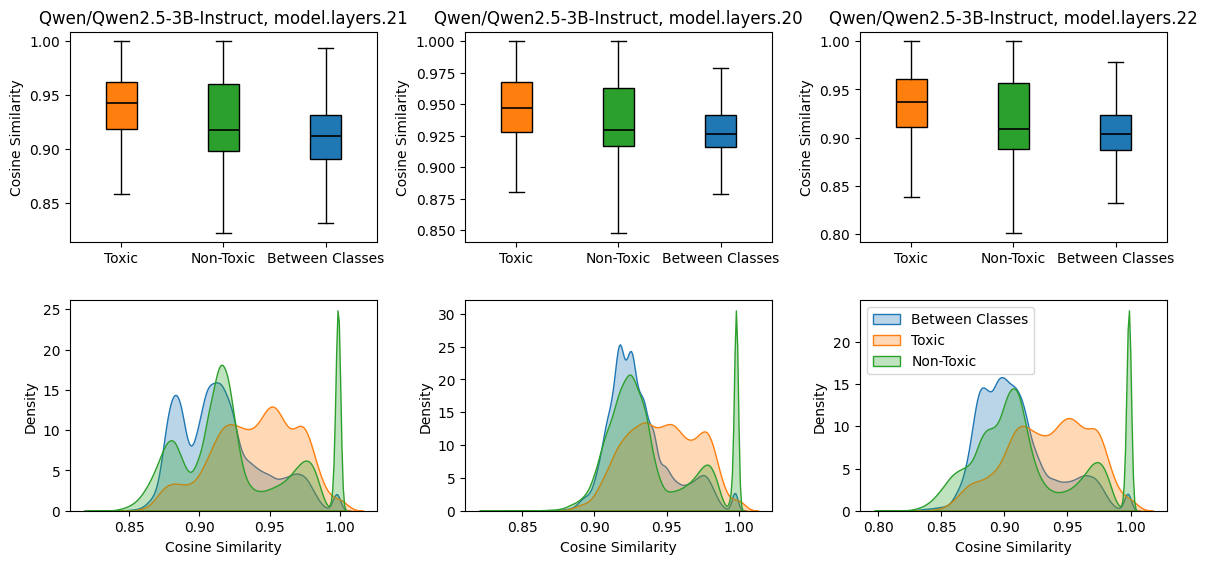

Processing model: allenai/OLMo-2-0425-1B, layer: model.layers.5
74 126
74 126
Model: allenai/OLMo-2-0425-1B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
92 458
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
92 458
289 907
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
289 907
136 301
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
136 301


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B, layer: model.layers.7
74 126
74 126
Model: allenai/OLMo-2-0425-1B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
92 458
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
92 458
289 907
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
289 907
136 301
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
136 301


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B, layer: model.layers.4
74 126
74 126
Model: allenai/OLMo-2-0425-1B, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
3 1149
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
3 1149
92 458
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
92 458
289 907
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
289 907
136 301
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
136 301


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


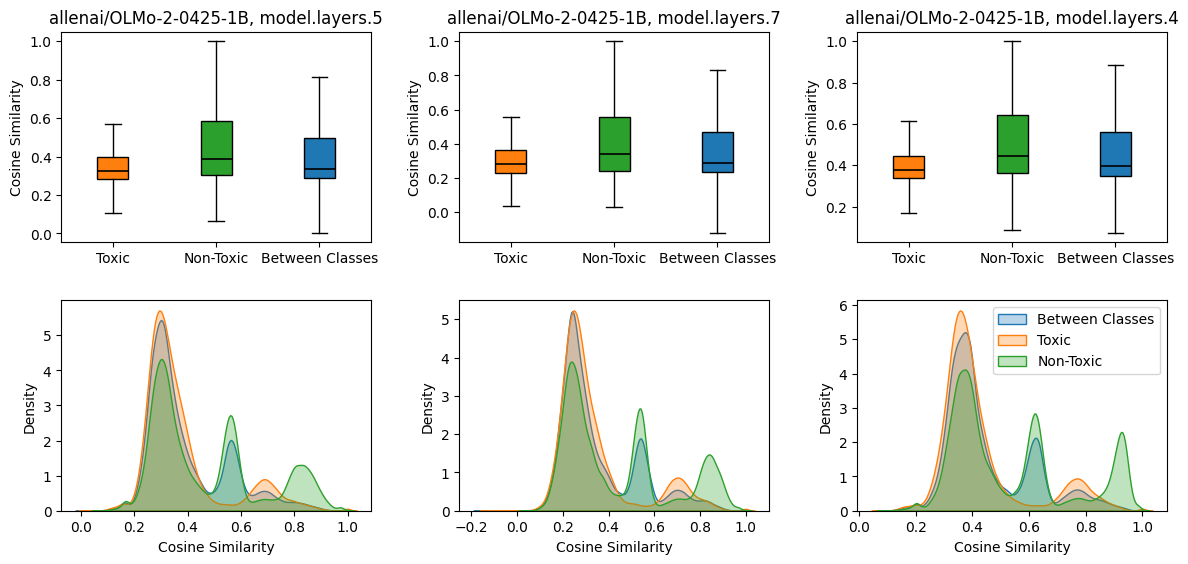

Processing model: allenai/OLMo-2-0425-1B-Instruct, layer: model.layers.9
20 180
20 180
Model: allenai/OLMo-2-0425-1B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
377 775
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
377 775
19 531
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
19 531
82 1114
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
82 1114
23 414
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
23 414


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B-Instruct, layer: model.layers.7
20 180
20 180
Model: allenai/OLMo-2-0425-1B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
377 775
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
377 775
19 531
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
19 531
82 1114
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
82 1114
23 414
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
23 414


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


Processing model: allenai/OLMo-2-0425-1B-Instruct, layer: model.layers.8
20 180
20 180
Model: allenai/OLMo-2-0425-1B-Instruct, Hidden states shape: torch.Size([200, 2048]), Labels shape: (200,)
377 775
  Dataset: walledai/DTStereotype, Hidden states shape: torch.Size([1152, 2048]), Labels shape: (1152,)
377 775
19 531
  Dataset: walledai/CatHarmfulQA, Hidden states shape: torch.Size([550, 2048]), Labels shape: (550,)
19 531
82 1114
  Dataset: walledai/DTToxicity, Hidden states shape: torch.Size([1196, 2048]), Labels shape: (1196,)
82 1114
23 414
  Dataset: truthfulqa/truthful_qa, Hidden states shape: torch.Size([437, 2048]), Labels shape: (437,)
23 414


/tmp/ipykernel_142970/3286511997.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


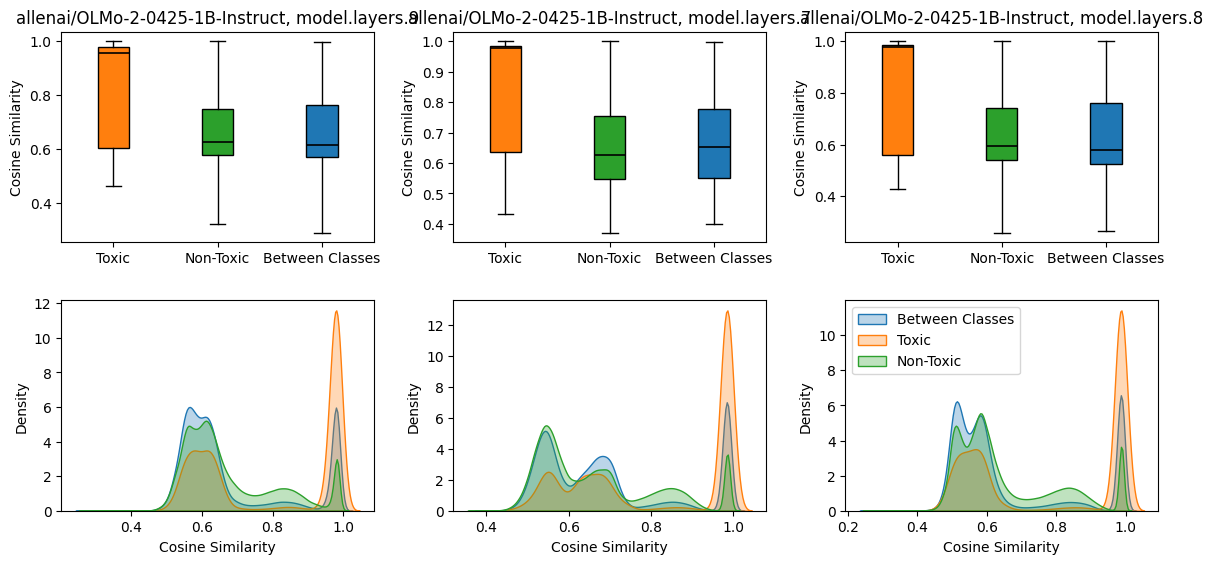

In [27]:
for model in models: 
    layers = model_steering_1[model]['layers']
    plt.figure(figsize=(12,8))
    for i, layer in enumerate(layers):
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        X_1, v1 = load_harmbench(model, output_dir)
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)
        order1 = np.argsort(v1)  # zeros first, then ones

        v1 = v1[order1] # for balanced plotting
        idx1 = torch.from_numpy(order1).long()
        X_1[layer] = X_1[layer].index_select(dim=0, index=idx1).float() # X
        X_1[layer] = F.normalize(X_1[layer], p=2, dim=1)
        cos = cosine_similarity(X_1[layer].numpy())
        print(sum(v1==1), sum(v1==0))
        X.append(X_1[layer].float().numpy())

        # plt.imshow(cos, cmap='hot', interpolation='nearest')
        # plt.colorbar()
        # plt.title(f"Cosine Similarity for {model}")
        # plt.show()
        # plt.close()

        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            order2 = np.argsort(v2)  # zeros first, then ones
            X.append(X_2[layer].float().numpy())
            y.append(v2)
            print(sum(v2==1), sum(v2==0))
            print(f"  Dataset: {data}, Hidden states shape: {X_2[layer].shape}, Labels shape: {v2.shape}")
            v2 = v2[order2] # for balanced plotting
            idx2 = torch.from_numpy(order2).long()
            X_2[layer] = X_2[layer].index_select(dim=0, index=idx2).float() # for balanced plotting
            X_2[layer] = F.normalize(X_2[layer], p=2, dim=1)
            cos = cosine_similarity(X_2[layer].numpy())
            print(sum(v2==1), sum(v2==0))

            # plt.imshow(cos, cmap='hot', interpolation='nearest')
            # plt.colorbar()
            # plt.title(f"Cosine Similarity {data}")
            # plt.show()
            # plt.close()

        X_all = np.concatenate(X, axis=0)
        X_c = cosine_similarity(X_all)
        y_all = np.concatenate(y, axis=0)
        cos_tox = X_c[y_all==1][:, y_all==1]
        cos_nontox = X_c[y_all==0][:, y_all==0]
        cos_between = X_c[y_all==1][:, y_all==0]

        data = [
            cos_tox.flatten(),
            cos_nontox.flatten(),
            cos_between.flatten()
            ]
        labels = ["Toxic", "Non-Toxic", "Between Classes"]
        colors = ["tab:orange", "tab:green", "tab:blue"]  # consistent colors

        plt.subplot(3, 3, i + 1)
        bp = plt.boxplot(
            data,
            labels=labels,
            patch_artist=True,  # allows coloring boxes
            widths=0.3,
            showfliers=False,   # hide the black dots (outliers)
        )

        # Apply custom colors
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            # patch.set_alpha(1)  # optional transparency

        # Optional: adjust median, whisker, and cap colors for readability
        for median in bp['medians']:
            median.set(color='black', linewidth=1.2)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        for mean in bp['means']:
            mean.set(color='black', marker='D', markeredgecolor='black')

        
        
        
        
        plt.title(f"{model}, {layer}")
        plt.ylabel("Cosine Similarity")

        plt.subplot(3, 3, i + 4)
        sns.kdeplot(cos_between.flatten(), color='tab:blue', fill=True, alpha=0.3)
        sns.kdeplot(cos_tox.flatten(), color='tab:orange', fill=True, alpha=0.3)
        sns.kdeplot(cos_nontox.flatten(), color='tab:green', fill=True, alpha=0.3)
        
        plt.ylabel("Density")
        plt.xlabel("Cosine Similarity")
    plt.legend(["Between Classes", "Toxic", "Non-Toxic"])
    # plt.ylim(0.7, 1.0)  # adjust based on your range
    plt.tight_layout()
    plt.show()
    plt.close()
    # plt.hist(cos_tox.flatten(), bins=50, alpha=0.3, color='tab:orange', density=True, label='Toxic')
    # plt.hist(cos_nontox.flatten(), bins=50, alpha=0.3, color='tab:green', density=True, label='Non-Toxic')
    # plt.hist(cos_between.flatten(), bins=50, alpha=0.3, color='tab:blue', density=True, label='Between Classes')

    # sns.kdeplot(cos_tox.flatten(), color='tab:orange')
    # sns.kdeplot(cos_nontox.flatten(), color='tab:green')
    # sns.kdeplot(cos_between.flatten(), color='tab:blue')
    # plt.axvline(np.median(cos_tox), color='tab:orange', linestyle='--', alpha=0.7)
    # plt.axvline(np.median(cos_nontox), color='tab:green', linestyle='--', alpha=0.7)
    # plt.axvline(np.median(cos_between), color='tab:blue', linestyle='--', alpha=0.7)


    # # sns.kdeplot(x=X_c[y_all==1][:, y_all==1].flatten())
    # # sns.kdeplot(x=X_c[y_all==0][:, y_all==0].flatten())
    # # sns.kdeplot(x=X_c[y_all==1][:, y_all==0].flatten())
    # plt.text(np.median(cos_tox), 5, f"{np.median(cos_tox):.2f}", color='tab:orange', ha='center')
    # plt.text(np.median(cos_nontox), 5, f"{np.median(cos_nontox):.2f}", color='tab:green', ha='center')
    # plt.text(np.median(cos_between), 5, f"{np.median(cos_between):.2f}", color='tab:blue', ha='center')

    # plt.title(f"Cosine Similarity Concatenated for model {model}")
    # plt.xlabel("Cosine Similarity")
    # plt.ylabel("Density")
    # plt.legend(["Toxic", "Non-Toxic", "Between Classes"])
    # plt.show()

    # plt.imshow(X_c, cmap='hot', interpolation='nearest')
    # plt.colorbar()
    # plt.title(f"Cosine Similarity Concatenated for model {model}")

    # model = umap.UMAP(n_neighbors=15, n_components=2, random_state=42, metric='cosine')
    # X_umap = model.fit(X_all)

    # plt.figure()
    # c = plt.cm.get_cmap("Set1", len(X))
    # for i, (X_, y_) in enumerate(zip(X, y)):
    #     # Embed the data set in 2 dimensions using the fitted model
    #     X_embedded = model.transform(X_)
    #     plt.subplot(3,3,i+1)
    #     # Plot the projected points and show the evaluation score
    #     plt.scatter(X_embedded[:, 0][y_ == 0], X_embedded[:, 1][y_ == 0], c=c(i), s=30, alpha=0.3, marker='o', zorder=1)

    #     plt.scatter(X_embedded[:, 0][y_ == 1], X_embedded[:, 1][y_ == 1], c=c(i), s=80, alpha=0.7, marker='x', zorder=2)
    # plt.title(f"UMAP Projection for model {model}")
    # plt.show()
    # plt.close()
    
    # print(f"Concatenated shape for model {model}: {X.shape}, Labels shape: {y.shape}")
    # plot_dim_reduction_comparison(X, y)


In [ ]:
for model in models: 
    layers = model_steering_1[model]['layers']
    plt.figure(figsize=(12,8))
    for i, layer in enumerate(layers):
        print(f"Processing model: {model}, layer: {layer}")
        X = []
        y = []
        X_1, v1 = load_harmbench(model, output_dir)
        print(sum(v1==1), sum(v1==0))
        v1 = (v1 > 0).astype(int)
        order1 = np.argsort(v1)  # zeros first, then ones

        v1 = v1[order1] # for balanced plotting
        idx1 = torch.from_numpy(order1).long()
        X_1[layer] = X_1[layer].index_select(dim=0, index=idx1).float() # X
        X_1[layer] = F.normalize(X_1[layer], p=2, dim=1)
        cos = cosine_similarity(X_1[layer].numpy())
        print(sum(v1==1), sum(v1==0))
        X.append(X_1[layer].float().numpy())

        # plt.imshow(cos, cmap='hot', interpolation='nearest')
        # plt.colorbar()
        # plt.title(f"Cosine Similarity for {model}")
        # plt.show()
        # plt.close()

        y.append(v1)
        print(f"Model: {model}, Hidden states shape: {X_1[layer].shape}, Labels shape: {v1.shape}")
        for data in datasets_list:
            X_2, v2 = load_datasets(model, data, output_dir)
            v2 = (v2 > 0).astype(int)
            order2 = np.argsort(v2)  # zeros first, then ones
            X.append(X_2[layer].float().numpy())
            y.append(v2)
            print(sum(v2==1), sum(v2==0))
            print(f"  Dataset: {data}, Hidden states shape: {X_2[layer].shape}, Labels shape: {v2.shape}")
            v2 = v2[order2] # for balanced plotting
            idx2 = torch.from_numpy(order2).long()
            X_2[layer] = X_2[layer].index_select(dim=0, index=idx2).float() # for balanced plotting
            X_2[layer] = F.normalize(X_2[layer], p=2, dim=1)
            cos = cosine_similarity(X_2[layer].numpy())
            print(sum(v2==1), sum(v2==0))

            # plt.imshow(cos, cmap='hot', interpolation='nearest')
            # plt.colorbar()
            # plt.title(f"Cosine Similarity {data}")
            # plt.show()
            # plt.close()

        X_all = np.concatenate(X, axis=0)
        X_c = cosine_similarity(X_all)
        y_all = np.concatenate(y, axis=0)
        cos_tox = X_c[y_all==1][:, y_all==1]
        cos_nontox = X_c[y_all==0][:, y_all==0]
        cos_between = X_c[y_all==1][:, y_all==0]

        data = [
            cos_tox.flatten(),
            cos_nontox.flatten(),
            cos_between.flatten()
            ]
        labels = ["Toxic", "Non-Toxic", "Between Classes"]
        colors = ["tab:orange", "tab:green", "tab:blue"]  # consistent colors

        plt.subplot(3, 3, i + 1)
        bp = plt.boxplot(
            data,
            labels=labels,
            patch_artist=True,  # allows coloring boxes
            widths=0.3,
            showfliers=False,   # hide the black dots (outliers)
        )

        # Apply custom colors
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            # patch.set_alpha(1)  # optional transparency

        # Optional: adjust median, whisker, and cap colors for readability
        for median in bp['medians']:
            median.set(color='black', linewidth=1.2)
        for whisker in bp['whiskers']:
            whisker.set(color='black', linewidth=1)
        for cap in bp['caps']:
            cap.set(color='black', linewidth=1)
        for mean in bp['means']:
            mean.set(color='black', marker='D', markeredgecolor='black')

        
        
        
        
        plt.title(f"{model}, {layer}")
        plt.ylabel("Cosine Similarity")

        plt.subplot(3, 3, i + 4)
        sns.kdeplot(cos_between.flatten(), color='tab:blue', fill=True, alpha=0.3)
        sns.kdeplot(cos_tox.flatten(), color='tab:orange', fill=True, alpha=0.3)
        sns.kdeplot(cos_nontox.flatten(), color='tab:green', fill=True, alpha=0.3)
        
        plt.ylabel("Density")
        plt.xlabel("Cosine Similarity")
    plt.legend(["Between Classes", "Toxic", "Non-Toxic"])
    # plt.ylim(0.7, 1.0)  # adjust based on your range
    plt.tight_layout()
    plt.show()
    plt.close()